In [7]:
import pandas as pd

In [8]:
df = pd.read_csv(r'C:\Users\Admin\OneDrive\Desktop\MACHINE LEARNING PROJECT\AUTOMPG.csv')

In [9]:
df.head()

,Unnamed: 0,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,0,307.0,8,130.0,3504,12.0,70,1,18.0
1,1,350.0,8,165.0,3693,11.5,70,1,15.0
2,2,318.0,8,150.0,3436,11.0,70,1,18.0
3,3,304.0,8,150.0,3433,12.0,70,1,16.0
4,4,302.0,8,140.0,3449,10.5,70,1,17.0


In [10]:
df.tail()

,Unnamed: 0,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
393,393,140.0,4,86.0,2790,15.6,82,1,27.0
394,394,97.0,4,52.0,2130,24.6,82,2,44.0
395,395,135.0,4,84.0,2295,11.6,82,1,32.0
396,396,120.0,4,79.0,2625,18.6,82,1,28.0
397,397,119.0,4,82.0,2720,19.4,82,1,31.0


In [11]:
df.columns

Index(['Unnamed: 0', 'displacement', 'cylinders', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'mpg'],
      dtype='str')

In [12]:
df.describe()

,Unnamed: 0,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,198.500000,193.425879,5.454774,104.469388,2970.424623,15.568090,76.010050,1.572864,23.514573
std,115.036951,104.269838,1.701004,38.491160,846.841774,2.757689,3.697627,0.802055,7.815984
min,0.000000,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,9.000000
25%,99.250000,104.250000,4.000000,75.000000,2223.750000,13.825000,73.000000,1.000000,17.500000
50%,198.500000,148.500000,4.000000,93.500000,2803.500000,15.500000,76.000000,1.000000,23.000000
75%,297.750000,262.000000,8.000000,126.000000,3608.000000,17.175000,79.000000,2.000000,29.000000
max,397.000000,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,46.600000


In [33]:
df.isnull().sum()

Unnamed: 0      0
displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

In [14]:
df['mpg'].value_counts()

mpg
13.0    20
14.0    19
18.0    17
15.0    16
26.0    14
        ..
28.1     1
30.7     1
24.2     1
22.4     1
44.0     1
Name: count, Length: 129, dtype: int64

array([[<Axes: title={'center': 'displacement'}>,
        <Axes: title={'center': 'cylinders'}>,
        <Axes: title={'center': 'horsepower'}>],
       [<Axes: title={'center': 'weight'}>,
        <Axes: title={'center': 'acceleration'}>,
        <Axes: title={'center': 'model_year'}>],
       [<Axes: title={'center': 'origin'}>,
        <Axes: title={'center': 'mpg'}>, <Axes: >]], dtype=object)

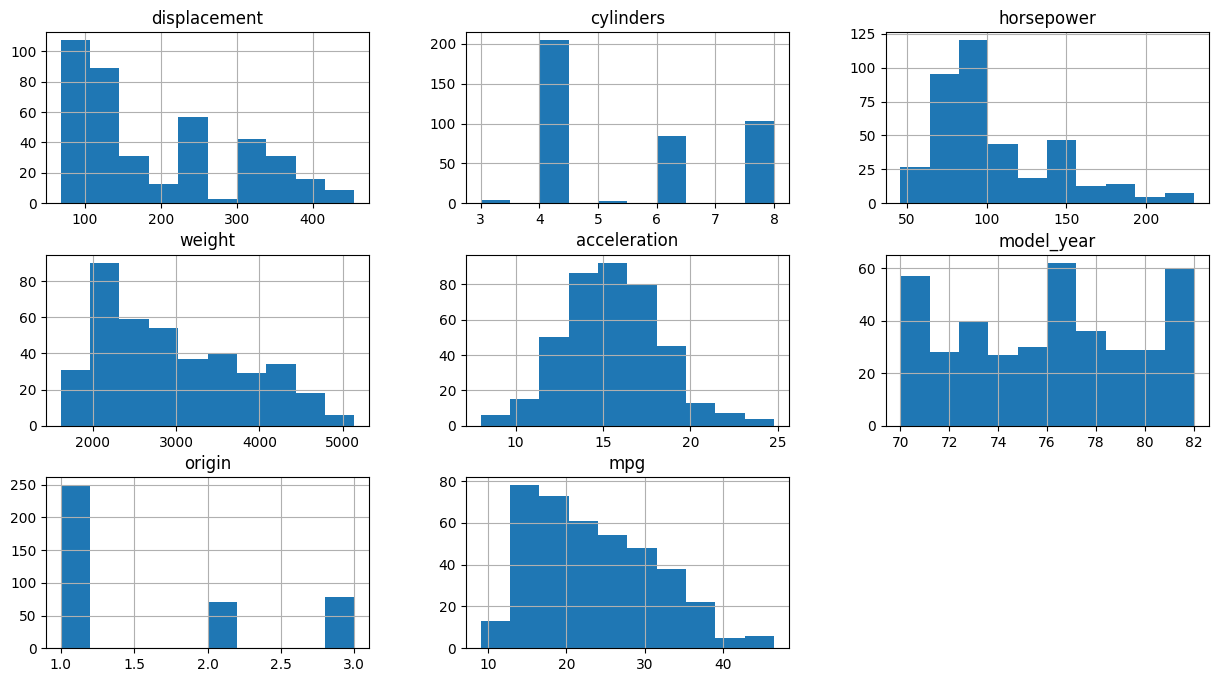

In [15]:
# Drop the 'Unnamed: 0' column and create histograms for the remaining columns
#Histograms for the column to represent the distribution of the data in each column which means.
clean_df = df.drop(['Unnamed: 0'], axis=1)
clean_df.hist(figsize=(15, 8))

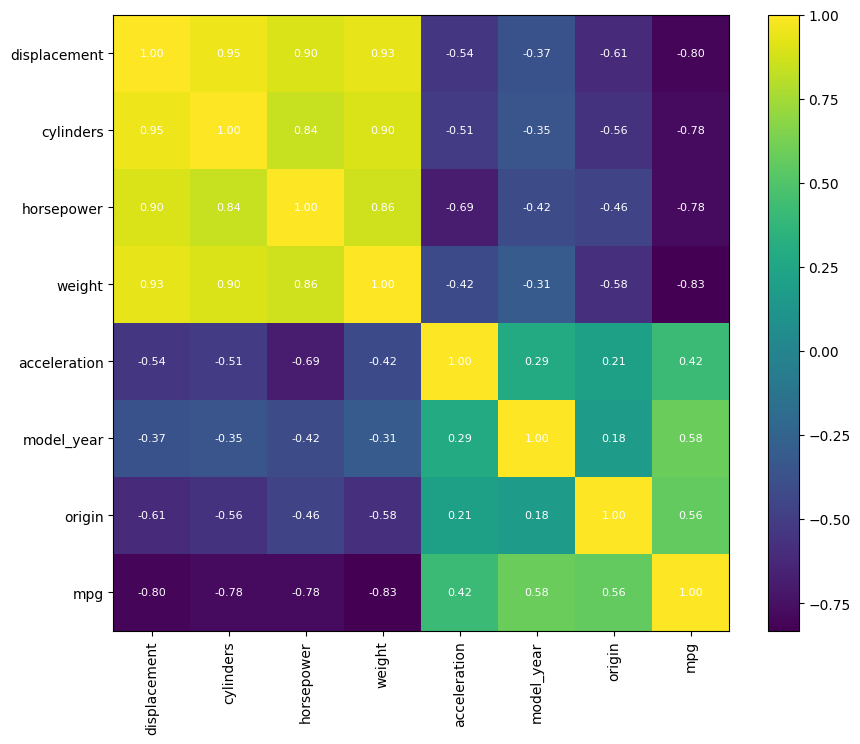

In [16]:
clean_df= df.drop(['Unnamed: 0'], axis=1)
try:
    import seaborn as sns
except ModuleNotFoundError:
    import matplotlib.pyplot as plt
    import numpy as np

    class _FakeSNS:
        @staticmethod
        def heatmap(data, annot=False, **kwargs):
            plt.figure(figsize=kwargs.get('figsize', (10, 8)))
            plt.imshow(data.values, cmap=kwargs.get('cmap', 'viridis'), interpolation='nearest')
            if annot:
                for (i, j), val in np.ndenumerate(data.values):
                    plt.text(j, i, f"{val:.2f}", ha='center', va='center', color='white', fontsize=8)
            plt.colorbar()
            plt.xticks(range(len(data)), data.columns, rotation=90)
            plt.yticks(range(len(data)), data.columns)
            plt.show()

    sns = _FakeSNS()
sns.heatmap(clean_df.corr(), annot=True)

In [17]:
x = df.drop(['Unnamed: 0','mpg'], axis=1)
Y = df['mpg']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, Y, test_size=0.2, random_state=42)

In [19]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [20]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
linear_regression_mse = mean_squared_error(y_test, y_pred)
linear_regression_r2 = r2_score(y_test, y_pred)
print("MSE:", linear_regression_mse)
print("R2:", linear_regression_r2)

MSE: 8.195643426571682
R2: 0.8475695460782324


In [23]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd

imputer = SimpleImputer(strategy='mean')

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# Scaling (required for SVR)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model2 = SVR()
model2.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [24]:
y_pred2 = model2.predict(X_test)

In [25]:
SVR_mse = mean_squared_error(y_test, y_pred2)
SVR_r2 = r2_score(y_test, y_pred2)
print('MSE:', SVR_mse)
print('R2:', SVR_r2)

MSE: 6.813655988041911
R2: 0.8732730767963074


In [26]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "SVR"],
    "MSE": [linear_regression_mse, SVR_mse],
    "R2": [linear_regression_r2, SVR_r2]
})

print(results)

               Model       MSE        R2
0  Linear Regression  8.195643  0.847570
1                SVR  6.813656  0.873273


In [27]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [28]:
mlp = MLPRegressor(hidden_layer_sizes=(64, 32,16), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [29]:
y_mlp = mlp.predict(X_test)

In [32]:
mlp.fit(X_train, y_train)
y_mlp = mlp.predict(X_test)

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
mse_mlp = mean_squared_error(y_test, y_mlp)
r2_mlp = r2_score(y_test, y_mlp)

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "SVR", "MLP"],
    "MSE": [mean_squared_error(y_test, y_pred), mean_squared_error(y_test, y_pred2), mean_squared_error(y_test, y_mlp)],
    "R2": [r2_score(y_test, y_pred), r2_score(y_test, y_pred2), r2_score(y_test, y_mlp)]
})

print(results)

               Model        MSE        R2
0  Linear Regression  13.735311  0.744537
1                SVR   6.813656  0.873273
2                MLP   5.121597  0.904744
